In [2]:
!pip uninstall -y timesfm
!pip install git+https://github.com/google-research/timesfm.git

  Cloning https://github.com/google-research/timesfm.git to /tmp/pip-req-build-n1_mc5ai
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm.git /tmp/pip-req-build-n1_mc5ai
  Encountered 4 file(s) that should have been pointers, but weren't:
        timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
        timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
        timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
        timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
  Resolved https://github.com/google-research/timesfm.git to commit ed29ec5ef7e2d86c48b632859de3b63856ef9cad
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-py3-none-any.whl size=43968 sha256=65c519709d95d1a2df7b68869acb1002fc8

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset Loaded:", df.shape)
print(df.head())
print(df.tail())

Dataset Loaded: (276, 6)
        Date  consump       Temp      US_EPU  wind_speed  Humidity
0 2001-01-01  2676998  32.036696  142.614125    1.974750    78.569
1 2001-02-01  2309464  36.140802  128.625655    1.958117    78.675
2 2001-03-01  2246633  41.352705  137.374157    1.692071    77.135
3 2001-04-01  1807170  55.933991  148.758003    2.256230    74.354
4 2001-05-01  1522382  64.001146  117.436256    1.874177    71.167
          Date  consump       Temp      US_EPU  wind_speed  Humidity
271 2023-08-01  2683066  75.371101   76.844224    1.631880    68.229
272 2023-09-01  2386277  69.306397  117.698777    1.569206    67.892
273 2023-10-01  2442786  57.773456  133.594075    1.672584    72.875
274 2023-11-01  2825894  45.685869  140.677204    1.892779    73.257
275 2023-12-01  3182367  41.362985  107.001579    1.665746    76.430


In [ ]:
# Replace inf
df = df.replace([np.inf, -np.inf], np.nan)

cols = ["Temp", "US_EPU", "wind_speed", "Humidity", "consump"]

# Interpolate
for col in cols:
    df[col] = df[col].interpolate()

# Fill remaining
df = df.bfill().ffill()

print("After Cleaning:\n", df.isna().sum())

In [5]:
temp = df["Temp"].values.astype(float)
wind = df["wind_speed"].values.astype(float)
epu = df["US_EPU"].values.astype(float)
humidity = df["Humidity"].values.astype(float)
consump = df["consump"].values.astype(float)

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(consump, model='additive', period=12)

trend = pd.Series(decomp.trend).bfill().ffill().to_numpy()
seasonal = decomp.seasonal

In [7]:
import timesfm

def timesfm_forecast(series, horizon=12):
    
    series = series[-96:]
    
    patch_size = 32
    usable_length = (len(series)//patch_size)*patch_size
    series = series[-usable_length:]
    
    mean = series.mean()
    std = series.std()
    
    series_norm = (series - mean) / std
    
    model = timesfm.TimesFM_2p5_200M_torch()
    config = timesfm.ForecastConfig(max_horizon=horizon)
    
    model.compile(config, global_batch_size=1)
    
    forecast, _ = model.forecast(horizon, [series_norm])
    
    pred = np.array(forecast[0])
    
    pred = pred * std + mean
    
    return pred

In [8]:
trend_tf = timesfm_forecast(trend)

temp_tf = timesfm_forecast(temp)
wind_tf = timesfm_forecast(wind)
epu_tf = timesfm_forecast(epu)
humidity_tf = timesfm_forecast(humidity)

In [9]:
seasonal_future = seasonal[-12:]

In [10]:
from sklearn.metrics import mean_absolute_error

best_score = float("inf")
best_params = None
best_forecast = None

actual = consump[-12:]

for scale in np.linspace(0.8, 1.5, 8):
    for season_strength in np.linspace(1.0, 2.5, 8):
        for peak_boost in np.linspace(1.0, 1.5, 5):
            for h_weight in np.linspace(0.0, 0.2, 5):
                
                # base reconstruction
                pred = trend_tf + season_strength * seasonal_future
                
                # 🔥 humidity correction
                humidity_effect = (humidity_tf - humidity.mean()) / humidity.std()
                pred = pred + h_weight * humidity_effect * consump.std()
                
                # scale
                pred = pred * scale
                
                # peak boost
                mean_val = pred.mean()
                pred = mean_val + peak_boost * (pred - mean_val)
                
                # evaluate
                error = mean_absolute_error(actual, pred)
                
                if error < best_score:
                    best_score = error
                    best_params = (scale, season_strength, peak_boost, h_weight)
                    best_forecast = pred

print("Best Params:", best_params)
print("Best MAE:", best_score)

Best Params: (np.float64(1.1), np.float64(1.0), np.float64(1.0), np.float64(0.15000000000000002))
Best MAE: 116160.20610088766


In [11]:
final_forecast = best_forecast

print("\n📌 Final Forecast:")
print(final_forecast)


📌 Final Forecast:
[3644303.43407645 3301128.62433789 3068814.25690313 2620793.91262305
 2364979.75586452 2365316.69458646 2564562.09732803 2605883.52812883
 2364454.91478743 2422126.10770711 2762521.08857058 3318383.92051406]


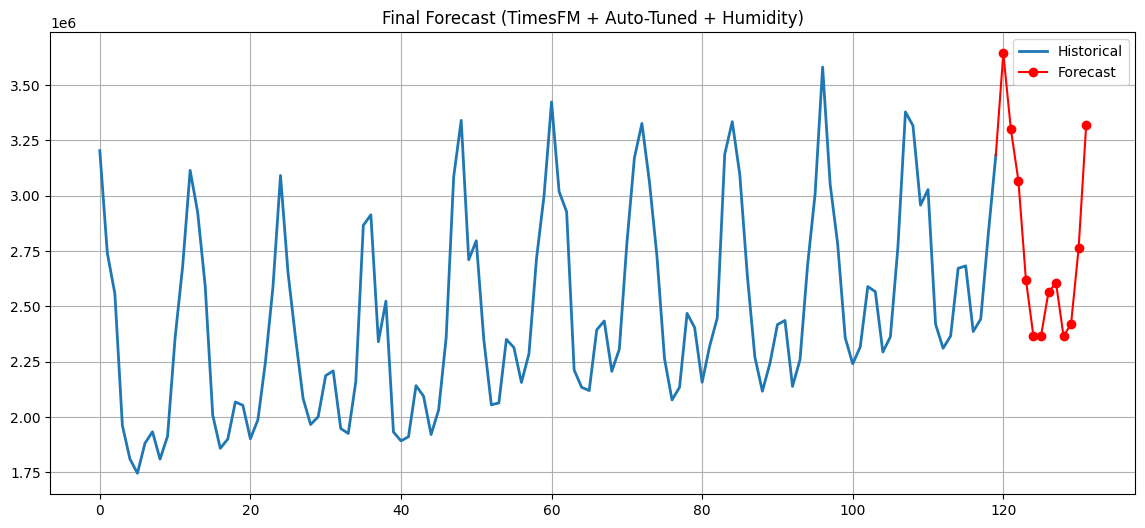

In [12]:
import matplotlib.pyplot as plt

history = consump[-120:]

hist_index = np.arange(len(history))
forecast_index = np.arange(len(history), len(history)+12)

plt.figure(figsize=(14,6))

plt.plot(hist_index, history, label="Historical", linewidth=2)

plt.plot(
    forecast_index,
    final_forecast,
    color="red",
    marker='o',
    label="Forecast"
)

plt.plot(
    [hist_index[-1], forecast_index[0]],
    [history[-1], final_forecast[0]],
    color="red"
)

plt.title("Final Forecast (TimesFM + Auto-Tuned + Humidity)")
plt.legend()
plt.grid()
plt.show()

In [13]:
plt.savefig("forecast.png")

<Figure size 640x480 with 0 Axes>